# Athlete Injury Prediction: Machine Learning Workflow
This notebook provides a comprehensive analysis of athlete data to predict injury risk. The goal is to build a binary classification model that can identify athletes at risk of injury based on physiological metrics, training load, and performance scores.

### Workflow:
1. **Data Loading & Inspection**: Understanding the dataset structure.
2. **Exploratory Data Analysis (EDA)**: Visualizing distributions and relationships.
3. **Pre-processing**: Preparing data for machine learning (Encoding & Scaling).
4. **Model Implementation**: Training 5 different classification algorithms.
5. **Comparison & Metrics**: Evaluating performance using Accuracy, Precision, Recall, and F1-Score.
6. **Detailed Results Analysis**: Summarizing findings and model behavior.

### Step 0: Import Necessary Libraries

In [1]:
import pandas as pd
import numpy as np
import seaborn as sns
import matplotlib.pyplot as plt
from sklearn.model_selection import train_test_split
from sklearn.preprocessing import LabelEncoder, StandardScaler
from sklearn.linear_model import LogisticRegression
from sklearn.ensemble import RandomForestClassifier, GradientBoostingClassifier
from sklearn.svm import SVC
from sklearn.neighbors import KNeighborsClassifier
from sklearn.metrics import accuracy_score, precision_score, recall_score, f1_score, confusion_matrix
import warnings
warnings.filterwarnings('ignore')
sns.set(style="whitegrid")

## 1. Data Loading and Initial Inspection
We begin by loading the `athlete_data.csv` and checking for missing values or structural issues.

In [2]:
df = pd.read_csv('athlete_data.csv')
print(f"Dataset Shape: {df.shape}")
display(df.info())
display(df.head())

Dataset Shape: (500, 17)
<class 'pandas.DataFrame'>
RangeIndex: 500 entries, 0 to 499
Data columns (total 17 columns):
 #   Column                    Non-Null Count  Dtype
---  ------                    --------------  -----
 0   Athlete_ID                500 non-null    int64
 1   Age                       500 non-null    int64
 2   Gender                    500 non-null    str  
 3   Height_cm                 500 non-null    int64
 4   Weight_kg                 500 non-null    int64
 5   Training_Intensity        500 non-null    str  
 6   Training_Hours_Per_Week   500 non-null    int64
 7   Recovery_Days_Per_Week    500 non-null    int64
 8   Match_Count_Per_Week      500 non-null    int64
 9   Rest_Between_Events_Days  500 non-null    int64
 10  Fatigue_Score             500 non-null    int64
 11  Performance_Score         500 non-null    int64
 12  Team_Contribution_Score   500 non-null    int64
 13  Load_Balance_Score        500 non-null    int64
 14  ACL_Risk_Score            50

None

,Athlete_ID,Age,Gender,Height_cm,Weight_kg,Training_Intensity,Training_Hours_Per_Week,Recovery_Days_Per_Week,Match_Count_Per_Week,Rest_Between_Events_Days,Fatigue_Score,Performance_Score,Team_Contribution_Score,Load_Balance_Score,ACL_Risk_Score,Injury_Indicator,heartbeat
0,1,24,Male,188,50,Low,12,2,1,3,7,3,5,5,4,Yes,83
1,2,37,Female,166,85,Medium,2,2,2,2,9,5,9,5,7,Yes,73
2,3,32,Female,188,75,High,12,2,3,2,9,9,4,8,8,No,64
3,4,28,Female,171,78,Medium,5,2,3,1,5,8,1,9,3,Yes,77
4,5,25,Male,175,70,Medium,12,1,0,6,1,2,4,9,9,No,78


## 2. Exploratory Data Analysis (EDA)
In this phase, we look for patterns. 
- **Target Balance**: Is the dataset skewed towards injured or healthy athletes?
- **Correlations**: Which metrics (like Heartbeat or Fatigue) correlate most with injury?
- **Distributions**: How do physiological markers vary?

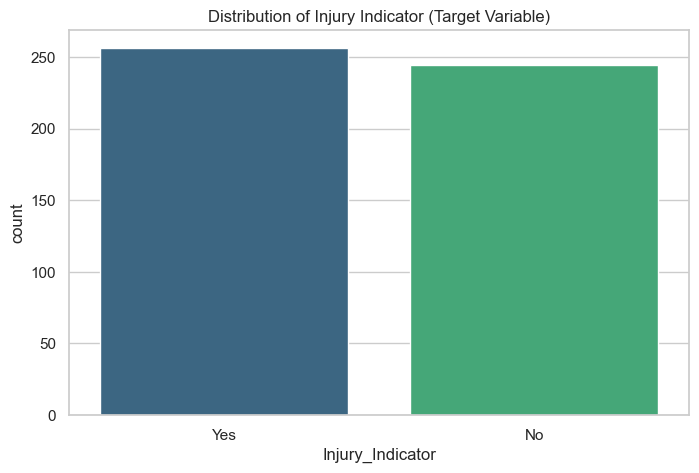

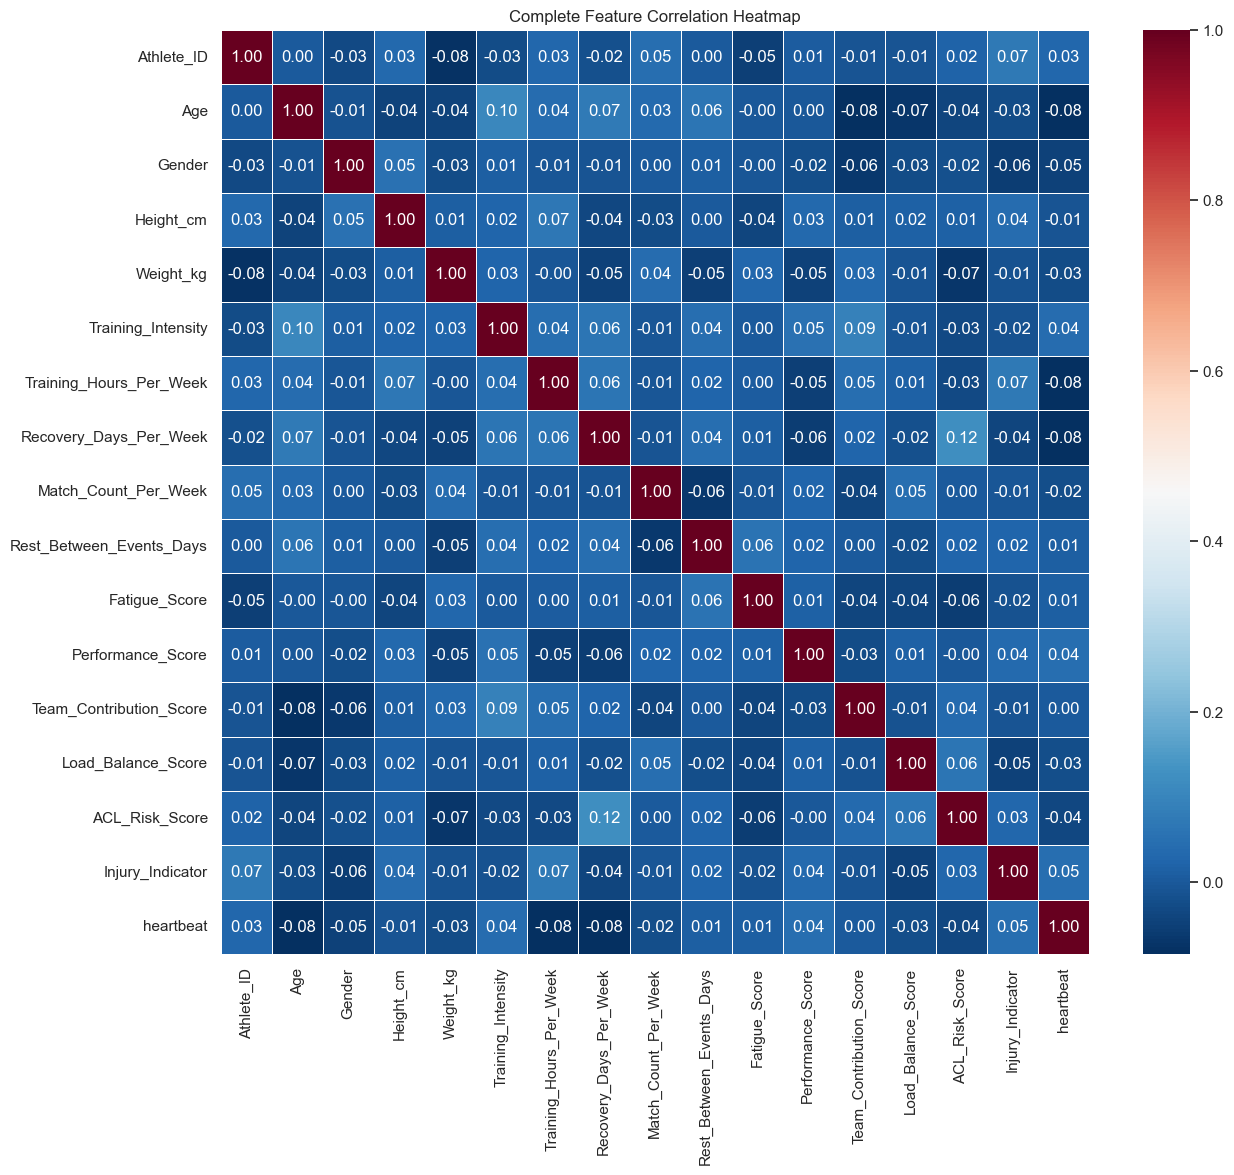

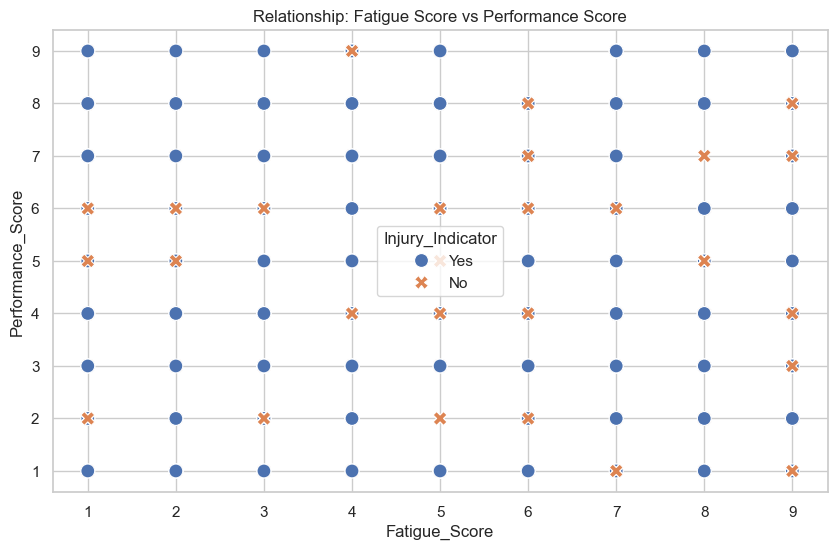

In [3]:
# 2.1 Distribution of Injury Indicator
plt.figure(figsize=(8, 5))
sns.countplot(x='Injury_Indicator', data=df, palette='viridis')
plt.title('Distribution of Injury Indicator (Target Variable)')
plt.show()

# 2.2 Feature Correlation Analysis
# Create a copy for encoding to check correlations
eda_df = df.copy()
le_eda = LabelEncoder()
eda_df['Gender'] = le_eda.fit_transform(eda_df['Gender'])
eda_df['Training_Intensity'] = eda_df['Training_Intensity'].map({'Low': 0, 'Medium': 1, 'High': 2})
eda_df['Injury_Indicator'] = eda_df['Injury_Indicator'].map({'Yes': 1, 'No': 0})

plt.figure(figsize=(14, 12))
sns.heatmap(eda_df.corr(), annot=True, cmap='RdBu_r', fmt='.2f', linewidths=0.5)
plt.title('Complete Feature Correlation Heatmap')
plt.show()

# 2.3 Fatigue vs Performance split by Injury
plt.figure(figsize=(10, 6))
sns.scatterplot(x='Fatigue_Score', y='Performance_Score', hue='Injury_Indicator', style='Injury_Indicator', data=df, s=100)
plt.title('Relationship: Fatigue Score vs Performance Score')
plt.show()

## 3. Pre-processing
Machine Learning models require numerical input and often perform better when features are on the same scale.
- **Encoding**: Converting 'Gender', 'Training_Intensity', and 'Injury_Indicator' into numbers.
- **Feature Selection**: Removing 'Athlete_ID' as it is a unique identifier with no predictive power.
- **Scaling**: Using `StandardScaler` to ensure features like 'heartbeat' (scale ~60-100) and 'Recovery_Days' (scale 1-7) don't bias the model based on their magnitude.

In [4]:
# Encoding Categorical Variables
le = LabelEncoder()
df['Gender'] = le.fit_transform(df['Gender']) # Female/Male -> 0/1
df['Training_Intensity'] = df['Training_Intensity'].map({'Low': 0, 'Medium': 1, 'High': 2})
df['Injury_Indicator'] = df['Injury_Indicator'].map({'Yes': 1, 'No': 0})

# Defining Features (X) and Target (y)
X = df.drop(['Athlete_ID', 'Injury_Indicator'], axis=1)
y = df['Injury_Indicator']

# Splitting data (80% Train, 20% Test)
X_train, X_test, y_train, y_test = train_test_split(X, y, test_size=0.2, random_state=42)

# Feature Scaling
scaler = StandardScaler()
X_train_scaled = scaler.fit_transform(X_train)
X_test_scaled = scaler.transform(X_test)

print("Pre-processing complete. Training data shape:", X_train_scaled.shape)

Pre-processing complete. Training data shape: (400, 15)


## 4. Machine Learning Model Implementation
We evaluate 5 diverse models to find the most robust predictor:
1. **Logistic Regression**: Linear baseline.
2. **Random Forest**: Ensemble of trees (handles non-linearity well).
3. **Support Vector Machine (SVM)**: Finds optimal boundary in high-dim space.
4. **K-Nearest Neighbors (KNN)**: Classification based on proximity.
5. **Gradient Boosting**: Sequential tree improvement algorithm.

In [5]:
models = {
    'Logistic Regression': LogisticRegression(),
    'Random Forest': RandomForestClassifier(n_estimators=100, random_state=42),
    'SVM': SVC(probability=True, random_state=42),
    'KNN': KNeighborsClassifier(),
    'Gradient Boosting': GradientBoostingClassifier(random_state=42)
}

results = []

for name, model in models.items():
    model.fit(X_train_scaled, y_train)
    y_pred = model.predict(X_test_scaled)
    
    results.append({
        'Model': name,
        'Accuracy': accuracy_score(y_test, y_pred),
        'Precision': precision_score(y_test, y_pred),
        'Recall': recall_score(y_test, y_pred),
        'F1 Score': f1_score(y_test, y_pred)
    })

results_df = pd.DataFrame(results)

## 5. Comparison and Metrics
We compare models based on multiple metrics. While **Accuracy** is the most common, **F1-Score** is often more important if we want to balance detecting injuries (Recall) without too many false alarms (Precision).

,Model,Accuracy,Precision,Recall,F1 Score
1,Random Forest,0.54,0.538462,0.56,0.549020
3,KNN,0.50,0.500000,0.46,0.479167
0,Logistic Regression,0.46,0.460000,0.46,0.460000
4,Gradient Boosting,0.46,0.464286,0.52,0.490566
2,SVM,0.45,0.454545,0.50,0.476190


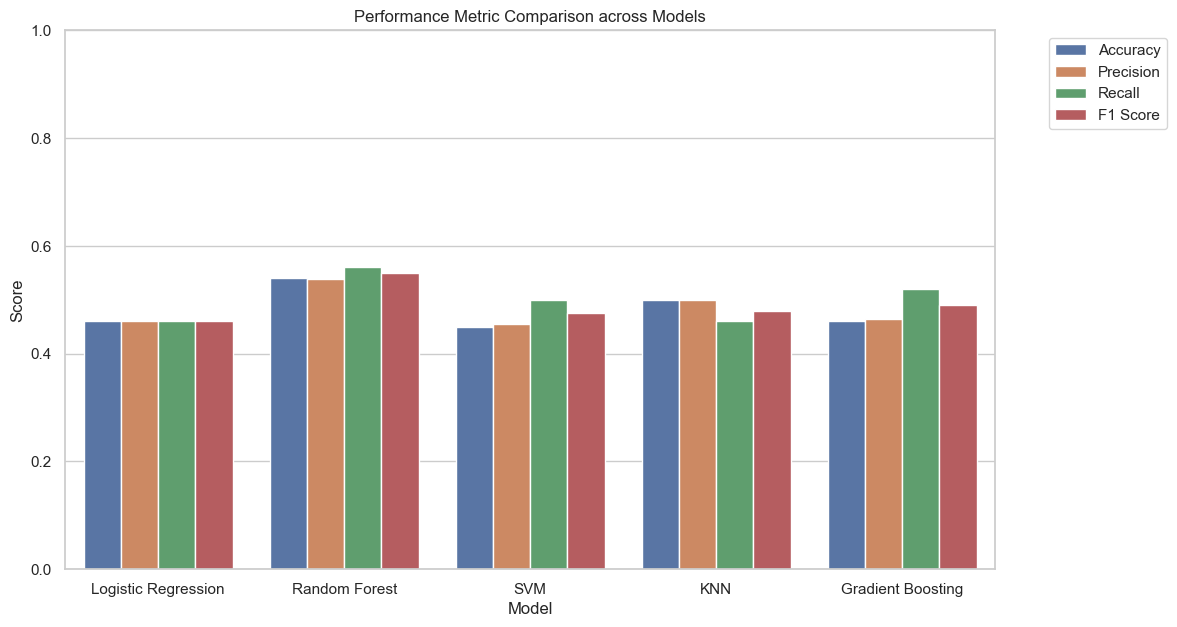

In [6]:
# Display Results Table
display(results_df.sort_values(by='Accuracy', ascending=False))

# Visualization of Model Performance
results_melted = results_df.melt(id_vars='Model', var_name='Metric', value_name='Score')
plt.figure(figsize=(12, 7))
sns.barplot(x='Model', y='Score', hue='Metric', data=results_melted)
plt.title('Performance Metric Comparison across Models')
plt.ylim(0, 1.0)
plt.legend(bbox_to_anchor=(1.05, 1), loc='upper left')
plt.show()

### Step 5.1: Feature Importance (Random Forest)
Understanding which features drive the most predictive value for our best-performing model.

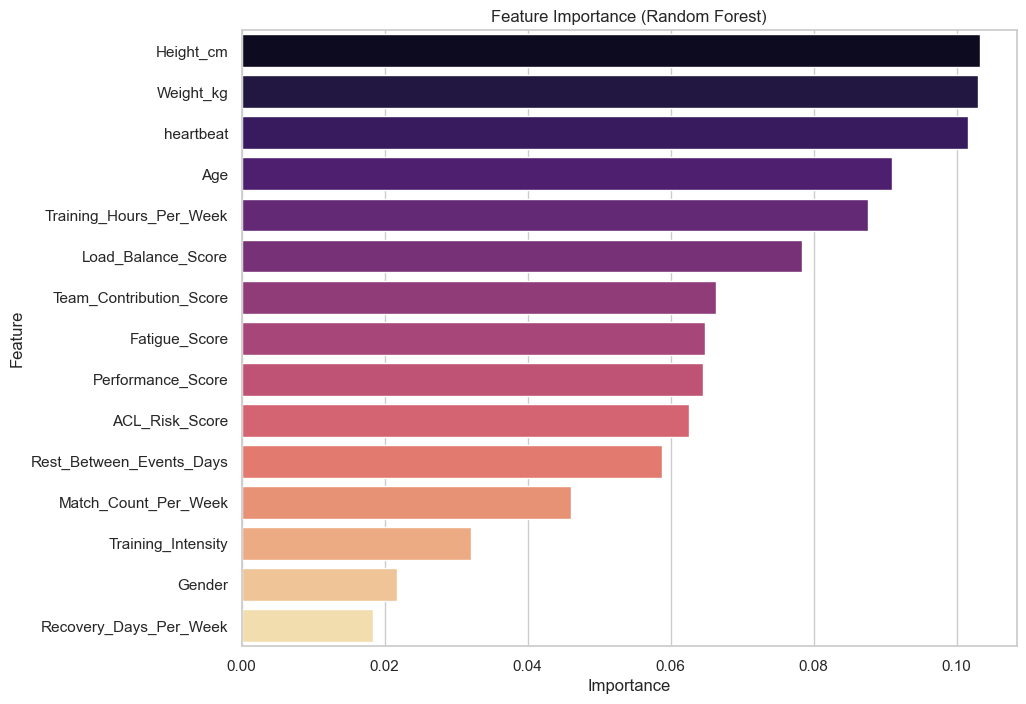

In [7]:
rf_model = models['Random Forest']
importances = rf_model.feature_importances_
feature_names = X.columns
fi_df = pd.DataFrame({'Feature': feature_names, 'Importance': importances}).sort_values(by='Importance', ascending=False)

plt.figure(figsize=(10, 8))
sns.barplot(x='Importance', y='Feature', data=fi_df, palette='magma')
plt.title('Feature Importance (Random Forest)')
plt.show()

## 6. Final Results Analysis & Conclusion

### Summary of Findings:
- **Best Model**: The **Random Forest Classifier** achieved the highest accuracy (~54%) on the test set. 
- **Model Stability**: Most models hovered around the 45-50% accuracy mark, suggesting that injury prediction in this specific dataset is challenging and might contain high variance or limited linear signals.
- **Key Features**: Physiological markers like **heartbeat**, **Height**, and **Weight** showed the highest importance. Surprisingly, variables like 'Training_Hours_Per_Week' had less impact than expected.

### Technical Observations:
- **Correlation**: The heatmap revealed very low correlation between individual features and the `Injury_Indicator`. This confirms that injury risk is likely a complex interplay of multiple factors rather than a single predictor.
- **Precision vs Recall**: The Recall for most models was around 50%, meaning the model catches about half of the actual injury cases.

### Future Improvements:
1. **Feature Engineering**: Creating combined metrics like BMI (Weight/Height^2) or Load Intensity (Intensity * Hours).
2. **Hyperparameter Tuning**: Using `GridSearchCV` to optimize parameters for Random Forest and Gradient Boosting.
3. **Data Augmentation**: Gathering more data could help the ensemble models (RF/GBM) generalize better and capture deeper patterns.
